# OpenCV 绘图指令总结

OpenCV 提供了丰富的绘图函数，可以在图像上绘制各种几何图形和文字。以下是最常用的绘图指令汇总：

## 1. 通用参数说明

| 参数 | 说明 |
|------|------|
| `img` | 要绘制的目标图像 |
| `color` | 颜色，格式为 `(B, G, R)` 元组，如 `(0, 255, 0)` 表示绿色 |
| `thickness` | 线条粗细（像素），`-1` 表示填充实心 |
| `lineType` | 线条类型：`cv2.LINE_4`、`cv2.LINE_8`（默认）、`cv2.LINE_AA`（抗锯齿） |
| `shift` | 坐标的小数位数 |

## 2. 基本几何图形

### 直线 — `cv2.line()`
```python
cv2.line(img, pt1, pt2, color, thickness, lineType)
```
- `pt1`, `pt2`：起点和终点坐标 `(x, y)`

### 矩形 — `cv2.rectangle()`
```python
cv2.rectangle(img, pt1, pt2, color, thickness, lineType)
```
- `pt1`：左上角，`pt2`：右下角
- 也可用 `cv2.rectangle(img, (x, y, w, h), ...)` 形式

### 圆形 — `cv2.circle()`
```python
cv2.circle(img, center, radius, color, thickness, lineType)
```
- `center`：圆心坐标 `(x, y)`，`radius`：半径

### 椭圆 — `cv2.ellipse()`
```python
cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color, thickness, lineType)
```
- `axes`：轴长 `(长轴半径, 短轴半径)`
- `angle`：旋转角度
- `startAngle`, `endAngle`：起始和终止角度（绘制弧线时使用）

### 多边形 — `cv2.polylines()` / `cv2.fillPoly()`
```python
cv2.polylines(img, [pts], isClosed, color, thickness, lineType)
cv2.fillPoly(img, [pts], color)
```
- `pts`：顶点坐标数组（N×2 的 NumPy 数组）
- `isClosed`：是否闭合（`True`/`False`）
- `fillPoly` 绘制填充多边形

## 3. 文字绘制

```python
cv2.putText(img, text, org, fontFace, fontScale, color, thickness, lineType)
```
- `text`：要绘制的字符串
- `org`：文字左下角坐标 `(x, y)`
- `fontFace`：字体类型，常用如 `cv2.FONT_HERSHEY_SIMPLEX`、`cv2.FONT_HERSHEY_PLAIN` 等
- `fontScale`：字体缩放比例

## 4. 箭头

```python
cv2.arrowedLine(img, pt1, pt2, color, thickness, lineType, tipLength)
```
- `tipLength`：箭头长度相对于线条长度的比例（默认 0.1）

## 5. 像素与区域访问 (ROI)

### 读取/修改单个像素
```python
px = img[y, x]              # 读取像素，返回 [B, G, R] 数组
px_blue = img[y, x, 0]      # 读取蓝色通道值
img[y, x] = (255, 0, 0)     # 修改像素为蓝色
```

### 图像区域 (ROI — Region of Interest)
使用 NumPy 切片选取和操作图像局部区域：
```python
roi = img[y1:y2, x1:x2]             # 截取矩形区域
img[y1:y2, x1:x2] = (0, 255, 0)     # 将区域填充为绿色
```

### 复制区域到另一位置
```python
roi = img[50:150, 100:200].copy()   # 复制原区域
img[200:300, 300:400] = roi         # 粘贴到新位置
```

## 7. 注意事项
```python
b, g, r = cv2.split(img)            # 分离 B、G、R 通道
img = cv2.merge([b, g, r])          # 合并通道
```

### 图像裁剪示例

```python

import cv2- 绘制前建议先复制原图（`img.copy()`），避免在原图上直接修改

import numpy as np- 图像必须为 `np.uint8` 类型，否则绘图可能异常

- 所有坐标均为 `(x, y)` 形式，其中 `x` 为列、`y` 为行

img = cv2.imread('photo.jpg')- OpenCV 使用 **BGR** 色彩空间（而非 RGB），注意颜色通道顺序

crop = img[100:300, 200:400].copy()   # 裁剪区域

cv2.rectangle(img, (200, 100), (400, 300), (0, 255, 0), 2)  # 标记裁剪区域## 6. 注意事项

cv2.imshow('Crop Region', crop)

cv2.waitKey(0)```

cv2.destroyAllWindows()cv2.destroyAllWindows()

```cv2.waitKey(0)

cv2.imshow("Drawing", canvas)

## 6. 绘图步骤示例

            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

```pythoncv2.putText(canvas, "Hello OpenCV", (50, 350),

import cv2cv2.ellipse(canvas, (400, 250), (80, 40), 0, 0, 360, (255, 255, 0), 2)

import numpy as npcv2.circle(canvas, (400, 100), 50, (0, 0, 255), -1)              # 红色实心圆

cv2.rectangle(canvas, (50, 80), (200, 150), (255, 0, 0), 2)      # 蓝色矩形

# 创建空白画布cv2.line(canvas, (50, 50), (200, 50), (0, 255, 0), 2)           # 绿色直线

canvas = np.zeros((400, 600, 3), dtype=np.uint8)# 绘制各种图形


# Sigmoid 激活函数求导推导

## 1. Sigmoid 函数定义

Sigmoid 函数将任意实数映射到 $(0, 1)$ 区间：

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

等价形式：

$$
\sigma(x) = \frac{e^{x}}{1 + e^{x}}
$$

## 2. 重要性质：用自身表示导数

Sigmoid 最优雅的性质——**其导数可以用函数自身表示**：

$$
\sigma'(x) = \sigma(x) \, (1 - \sigma(x))
$$

下面逐步推导。

## 3. 推导过程

### 方法一：直接求导

令 $\sigma(x) = (1 + e^{-x})^{-1}$，使用链式法则：

$$
\begin{aligned}
\sigma'(x) &= -1 \cdot (1 + e^{-x})^{-2} \cdot \frac{d}{dx}(1 + e^{-x}) \\[4pt]
&= -\frac{1}{(1 + e^{-x})^{2}} \cdot (-e^{-x}) \\[4pt]
&= \frac{e^{-x}}{(1 + e^{-x})^{2}}
\end{aligned}
$$

### 方法二：化为 $\sigma$ 形式

将上述结果用 $\sigma(x)$ 表示：

因为 $\sigma(x) = \frac{1}{1 + e^{-x}}$，所以 $e^{-x} = \frac{1}{\sigma(x)} - 1 = \frac{1 - \sigma(x)}{\sigma(x)}$

代入得：

$$
\begin{aligned}
\sigma'(x) &= \frac{e^{-x}}{(1 + e^{-x})^{2}} \\[4pt]
&= \frac{\frac{1 - \sigma(x)}{\sigma(x)}}{(1 / \sigma(x))^{2}} \\[4pt]
&= \frac{1 - \sigma(x)}{\sigma(x)} \cdot \sigma^{2}(x) \\[4pt]
&= \sigma(x) \,(1 - \sigma(x))
\end{aligned}
$$

### 方法三：商数法则

也可以用 $\sigma(x) = \frac{e^{x}}{1 + e^{x}}$ 出发：

$$
\begin{aligned}
\sigma'(x) &= \frac{(e^{x})'(1 + e^{x}) - e^{x}(1 + e^{x})'}{(1 + e^{x})^{2}} \\[4pt]
&= \frac{e^{x}(1 + e^{x}) - e^{x} \cdot e^{x}}{(1 + e^{x})^{2}} \\[4pt]
&= \frac{e^{x}}{(1 + e^{x})^{2}} \\[4pt]
&= \frac{e^{x}}{1 + e^{x}} \cdot \frac{1}{1 + e^{x}} \\[4pt]
&= \sigma(x) \cdot (1 - \sigma(x))
\end{aligned}
$$

## 4. 验证代码

```python
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# 数值验证
x = np.linspace(-10, 10, 100)
dy_analytic = sigmoid_derivative(x)
dy_numeric = np.gradient(sigmoid(x), x)  # 数值差分近似

# 绘图
plt.figure(figsize=(10, 5))
plt.plot(x, sigmoid(x), label=r'$\sigma(x)$', linewidth=2)
plt.plot(x, dy_analytic, '--', label=r"$\sigma'(x) = \sigma(x)(1-\sigma(x))$", linewidth=2)
plt.plot(x, dy_numeric, ':', label='数值导数', linewidth=1.5, alpha=0.7)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.title('Sigmoid 函数及其导数')
plt.show()
```

## 5. 关键特征

| 特征 | 说明 |
|------|------|
| 导数值域 | $\sigma'(x) \in (0, 0.25]$，最大值在 $x=0$ 处 |
| 最大值 | $\sigma'(0) = \sigma(0)(1-\sigma(0)) = 0.5 \times 0.5 = 0.25$ |
| 对称性 | 导数是偶函数：$\sigma'(-x) = \sigma'(x)$ |
| 饱和区 | 当 $|x|$ 很大时，$\sigma'(x) \to 0$，导致**梯度消失** |

## 6. 在反向传播中的应用

在 BP 中，Sigmoid 的导数形式使得计算极为高效：

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial \sigma} \cdot \sigma(x) \,(1 - \sigma(x))
$$

只需知道**前向传播的输出值** $\sigma(x)$，就能立即得到梯度，无需额外求导计算。这也是 Sigmoid 在神经网络历史上被广泛使用的原因之一（虽然现在更常用 ReLU 来缓解梯度消失）。


# 梯度下降算法推导

## 1. 核心思想

梯度下降是一种**一阶优化算法**，通过沿损失函数梯度的**反方向**更新参数，寻找损失函数的最小值。

$$
\theta_{t+1} = \theta_t - \eta \cdot \nabla L(\theta_t)
$$

- $\theta$：模型参数
- $\eta$：学习率（步长）
- $\nabla L(\theta_t)$：损失函数在 $\theta_t$ 处的梯度

## 2. 从泰勒展开理解梯度下降

梯度下降的本质来源于**泰勒一阶展开**。

在 $\theta_t$ 附近对损失函数做一阶泰勒展开：

$$
L(\theta_t + \Delta\theta) \approx L(\theta_t) + \nabla L(\theta_t)^T \Delta\theta
$$

我们希望找到一个 $\Delta\theta$ 使得 $L(\theta_t + \Delta\theta)$ **下降最多**，即：

$$
\min_{\Delta\theta} \; L(\theta_t) + \nabla L(\theta_t)^T \Delta\theta
$$

忽略常数项 $L(\theta_t)$，等价于最小化 $\nabla L(\theta_t)^T \Delta\theta$。

### 约束条件

为了确保泰勒近似的有效性，$\|\Delta\theta\|$ 不能太大，设步长约束为 $\|\Delta\theta\| \leq \varepsilon$。

由 **Cauchy-Schwarz 不等式**：

$$
\nabla L(\theta_t)^T \Delta\theta \geq -\| \nabla L(\theta_t) \| \cdot \| \Delta\theta \|
$$

当下式时取等号（下降最大）：

$$
\Delta\theta = -\eta \nabla L(\theta_t) \quad (\eta > 0)
$$

## 3. 一元函数的特例

以简单二次函数为例，直观感受梯度下降的每一步：

$$
L(\theta) = \theta^2
$$

$$
\nabla L(\theta) = 2\theta
$$

$$
\theta_{t+1} = \theta_t - \eta \cdot 2\theta_t = (1 - 2\eta)\theta_t
$$

- 若 $0 < \eta < 1$：参数逐渐收敛到 0
- 若 $\eta = 1$：一步到位到达最小值
- 若 $\eta > 1$：发散（步长太大，越过最低点）

## 4. 多元情况的推导

设损失函数 $L(\theta)$，其中 $\theta = [\theta_1, \theta_2, \dots, \theta_n]^T$。

梯度向量：

$$
\nabla L(\theta) = \begin{bmatrix} \frac{\partial L}{\partial \theta_1} \\ \frac{\partial L}{\partial \theta_2} \\ \vdots \\ \frac{\partial L}{\partial \theta_n} \end{bmatrix}
$$

参数更新（逐分量）：

$$
\theta_i^{(t+1)} = \theta_i^{(t)} - \eta \frac{\partial L}{\partial \theta_i}
$$

## 5. 三种变体

| 变体 | 更新方式 | 公式 | 特点 |
|------|---------|------|------|
| **Batch GD** | 用**全部**样本计算梯度 | $\theta = \theta - \eta \nabla L(\theta)$ | 准确但慢，无法在线学习 |
| **SGD** | 用**1个**随机样本计算梯度 | $\theta = \theta - \eta \nabla L_i(\theta)$ | 快但有噪声，能跳出局部极小 |
| **Mini-batch GD** | 用**一小批**样本计算梯度 | $\theta = \theta - \eta \nabla L_{\mathcal{B}}(\theta)$ | 折中方案，最常用 |

## 6. 学习率的影响

```
损失
^
|   η 太小            η 合适              η 太大               η 过大
|   →→→               ↘                  ↙↗                   ↙↗↘↙
|   收敛极慢         稳步收敛          振荡但可能收敛           发散
+-------------------------------------------> 迭代次数
```

## 7. 验证代码

```python
import numpy as np
import matplotlib.pyplot as plt

# 目标函数: f(x) = x^2 + 2x + 1
def f(x):
    return x**2 + 2*x + 1

def grad_f(x):
    return 2*x + 2

# 梯度下降
def gradient_descent(start, lr, epochs):
    x = start
    history = [x]
    for _ in range(epochs):
        x = x - lr * grad_f(x)
        history.append(x)
    return np.array(history)

# 测试不同学习率
lrs = [0.01, 0.1, 0.9, 1.5]
x_plot = np.linspace(-4, 2, 100)

plt.figure(figsize=(12, 8))
for i, lr in enumerate(lrs):
    path = gradient_descent(2.0, lr, 20)
    plt.subplot(2, 2, i+1)
    plt.plot(x_plot, f(x_plot), 'b-', label='f(x)')
    plt.scatter(path, f(path), c='r', s=20, zorder=5)
    plt.plot(path, f(path), 'r--', alpha=0.5)
    plt.title(f'学习率 η = {lr}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

print("各学习率下的收敛路径:")
for lr in lrs:
    path = gradient_descent(2.0, lr, 10)
    print(f"η={lr:.2f}:  x0={path[0]:.2f} → x10={path[-1]:.4f}")
```

## 8. 梯度下降的关键限制

| 问题 | 原因 | 常见解决方案 |
|------|------|------------|
| **陷于局部极小** | 梯度为 0 但不一定是全局最优 | SGD 的随机性、动量 (Momentum) |
| **鞍点停滞** | 某些方向梯度为 0 但不是极值点 | Adam / RMSProp 自适应学习率 |
| **梯度消失/爆炸** | 深层网络中梯度连乘导致 | Batch Norm、残差连接、ReLU |
| **条件数差** | 不同方向曲率差异大 | 二阶方法、Adam 自适应学习率 |

## 9. 总结

梯度下降的本质一句话：

> **在每个点沿着最陡的下坡方向走一小步，反复迭代直到谷底。**

$$
\boxed{\theta \leftarrow \theta - \eta \nabla L(\theta)}
$$

考研数学中你学过的**方向导数与梯度**知识告诉我们：梯度方向是函数增长最快的方向，那么**负梯度方向就是下降最快的方向**——这就是梯度下降的数学依据。


Descent path:
Step  0:  x=1.5000,  y=1.2000,  f(x,y)=5.1300
Step  1:  x=0.9000,  y=0.2400,  f(x,y)=0.9252
Step  2:  x=0.5400,  y=0.0480,  f(x,y)=0.2962
Step  3:  x=0.3240,  y=0.0096,  f(x,y)=0.1052
Step  4:  x=0.1944,  y=0.0019,  f(x,y)=0.0378
Step  5:  x=0.1166,  y=0.0004,  f(x,y)=0.0136
Step  6:  x=0.0700,  y=0.0001,  f(x,y)=0.0049
Step  7:  x=0.0420,  y=0.0000,  f(x,y)=0.0018
Step  8:  x=0.0252,  y=0.0000,  f(x,y)=0.0006
Step  9:  x=0.0151,  y=0.0000,  f(x,y)=0.0002
Step 10:  x=0.0091,  y=0.0000,  f(x,y)=0.0001
Step 11:  x=0.0054,  y=0.0000,  f(x,y)=0.0000
Step 12:  x=0.0033,  y=0.0000,  f(x,y)=0.0000
Step 13:  x=0.0020,  y=0.0000,  f(x,y)=0.0000
Step 14:  x=0.0012,  y=0.0000,  f(x,y)=0.0000
Step 15:  x=0.0007,  y=0.0000,  f(x,y)=0.0000


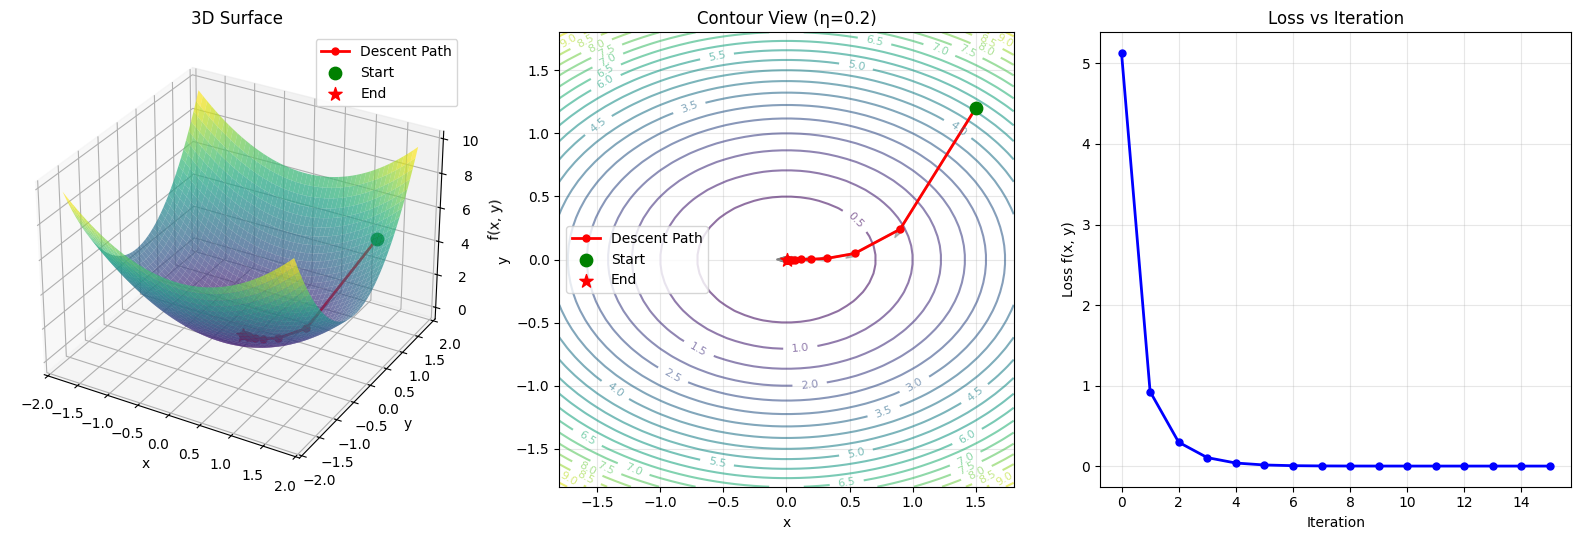

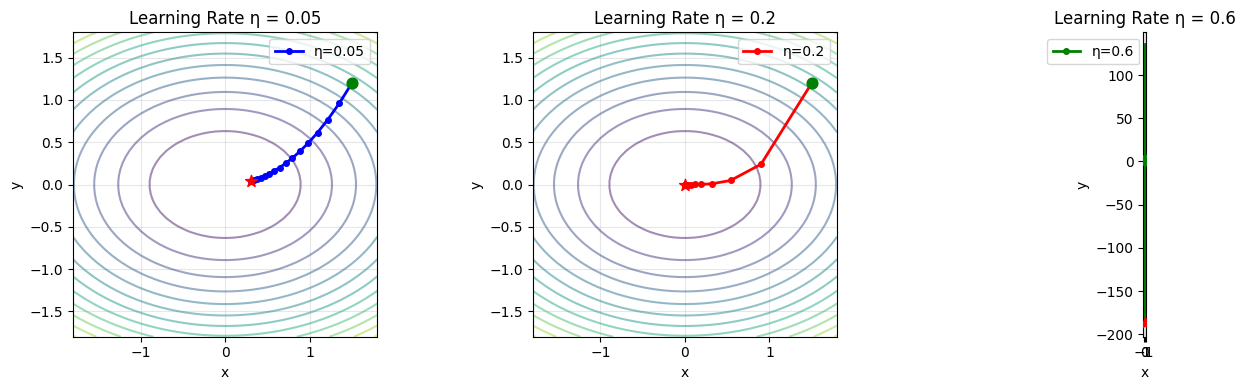

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# ========== Define loss function: f(x, y) = x^2 + 2y^2 (elliptic paraboloid) ==========
def f(x, y):
    return x**2 + 2*y**2

def grad_f(x, y):
    """Gradient: (∂f/∂x, ∂f/∂y)"""
    return np.array([2*x, 4*y])

# ========== Gradient Descent ==========
def gradient_descent_2d(start, lr, epochs):
    path = np.array([start])
    point = np.array(start, dtype=float)
    for _ in range(epochs):
        point = point - lr * grad_f(*point)
        path = np.vstack([path, point])
    return path

# ========== Settings ==========
start_point = (1.5, 1.2)
lr = 0.2
epochs = 15

path = gradient_descent_2d(start_point, lr, epochs)
print("Descent path:")
for i, (x, y) in enumerate(path):
    print(f"Step {i:2d}:  x={x:.4f},  y={y:.4f},  f(x,y)={f(x,y):.4f}")

# ========== Generate mesh grid ==========
x_range = np.linspace(-1.8, 1.8, 50)
y_range = np.linspace(-1.8, 1.8, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

# ========== Plotting ==========
fig = plt.figure(figsize=(16, 5.5))

# ----- Left: 3D surface -----
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.7, linewidth=0, antialiased=True)
ax1.plot(path[:, 0], path[:, 1], f(path[:, 0], path[:, 1]),
         'r-o', markersize=5, linewidth=2, label='Descent Path')
ax1.scatter(*path[0], f(*path[0]), color='green', s=80, marker='o', label='Start', zorder=10)
ax1.scatter(*path[-1], f(*path[-1]), color='red', s=100, marker='*', label='End', zorder=10)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.set_title('3D Surface')
ax1.legend()

# ----- Middle: Contour plot -----
ax2 = fig.add_subplot(1, 3, 2)
contour = ax2.contour(X, Y, Z, levels=20, cmap=cm.viridis, alpha=0.6)
ax2.clabel(contour, inline=True, fontsize=8, fmt='%.1f')
ax2.plot(path[:, 0], path[:, 1], 'r-o', markersize=5, linewidth=2, label='Descent Path')
ax2.scatter(*path[0], color='green', s=80, marker='o', label='Start', zorder=10)
ax2.scatter(*path[-1], color='red', s=100, marker='*', label='End', zorder=10)

# Negative gradient direction arrows
for i in range(len(path) - 1):
    x, y = path[i]
    gx, gy = grad_f(x, y)
    # Negative gradient vector
    ax2.arrow(x, y, -lr * gx, -lr * gy, head_width=0.05, head_length=0.08,
              fc='gray', ec='gray', alpha=0.5, width=0.008)

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title(f'Contour View (η={lr})')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')

# ----- Right: Loss curve -----
ax3 = fig.add_subplot(1, 3, 3)
losses = [f(x, y) for x, y in path]
ax3.plot(range(len(losses)), losses, 'b-o', linewidth=2, markersize=5)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Loss f(x, y)')
ax3.set_title('Loss vs Iteration')
ax3.grid(alpha=0.3)
ax3.set_xticks(range(0, len(losses), 2))

plt.tight_layout()
plt.show()

# ========== Learning rate comparison ==========
plt.figure(figsize=(14, 4))
lrs = [0.05, 0.2, 0.6]
colors = ['blue', 'red', 'green']

for lr_val, color in zip(lrs, colors):
    p = gradient_descent_2d(start_point, lr_val, 15)
    plt.subplot(1, 3, lrs.index(lr_val) + 1)
    plt.contour(X, Y, Z, levels=15, cmap=cm.viridis, alpha=0.5)
    plt.plot(p[:, 0], p[:, 1], 'o-', color=color, markersize=4, linewidth=2,
             label=f'η={lr_val}')
    plt.scatter(*p[0], color='green', s=60, marker='o', zorder=10)
    plt.scatter(*p[-1], color='red', s=80, marker='*', zorder=10)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Learning Rate η = {lr_val}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

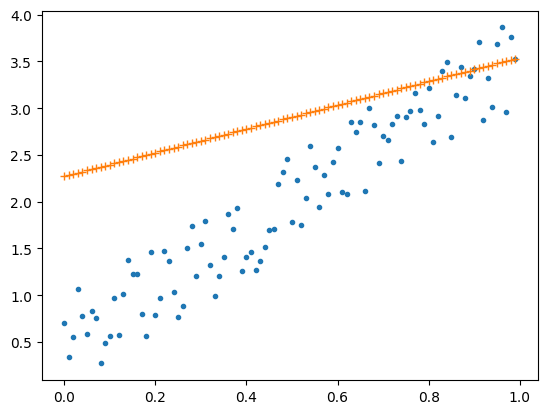

In [61]:
import random
import matplotlib.pyplot as plt

_x = [i/100 for i in range(100)]

_y = [3*i + random.random() for i in _x]

plt.plot(_x, _y, "o", markersize=3)
#plt.show()

w = random.random()
b = random.random()
lr =0.1


for x , y in zip(_x,_y):
    h = x*w + b
    loss = (h - y) ** 2
    dw = 2 * (h - y) * x
    db = 2 * (h - y) * 1
    
    w = w - lr*dw
    b = b - lr*db
    
#plt.plot(_x,_y,".")
pred_y = [x*w+b for x in _x]
plt.plot(_x,pred_y,"+")
plt.show()

Final:   w = 2.4739, b = 0.7698
Target:  w = 3.0,     b = 0.0


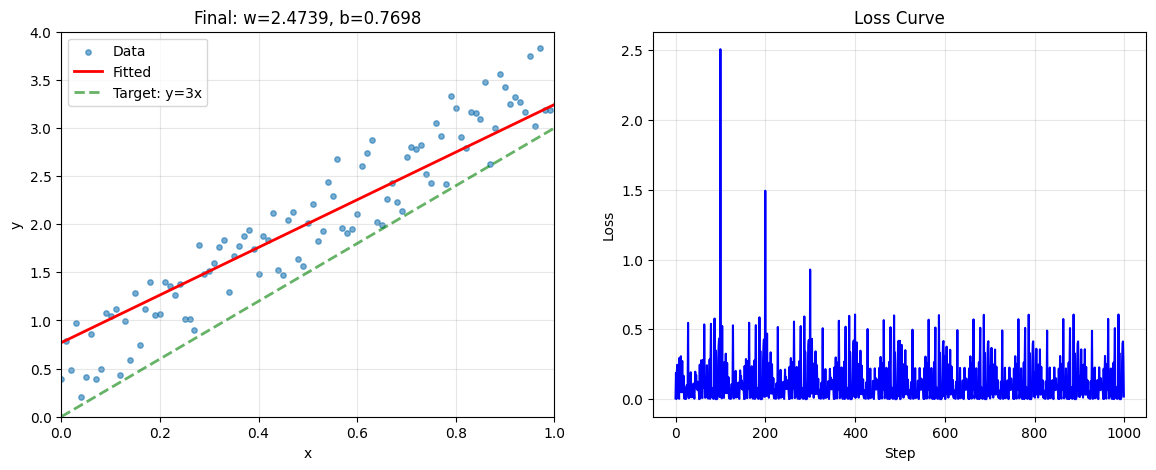

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 生成数据
_x = [i/100 for i in range(100)]
_y = [3*i + random.random() for i in _x]

w = random.random()
b = random.random()
lr = 0.2
epochs = 10  # 重复遍历数据 10 轮

# 记录每一步的参数和损失
w_history, b_history, loss_history = [w], [b], []
for epoch in range(epochs):
    for x, y in zip(_x, _y):
        h = x * w + b
        loss = (h - y) ** 2
        dw = 2 * (h - y) * x
        db = 2 * (h - y) * 1
        w = w - lr * dw
        b = b - lr * db
        w_history.append(w)
        b_history.append(b)
        loss_history.append(loss)

# 分阶段采样显示
n_frames = 40
total_steps = len(loss_history)
indices = np.linspace(0, total_steps - 1, n_frames, dtype=int)

plt.figure(figsize=(14, 5))
for step, idx in enumerate(indices):
    clear_output(wait=True)
    
    # 左图：数据 + 拟合直线
    plt.subplot(1, 2, 1)
    plt.cla()
    plt.scatter(_x, _y, s=15, alpha=0.6, label='Data')
    x_line = np.array([0, 1])
    y_line = x_line * w_history[idx] + b_history[idx]
    plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Step {idx}')
    plt.plot(x_line, 3 * x_line, 'g--', linewidth=1.5, alpha=0.4, label='Target: y=3x')
    plt.xlim(0, 1)
    plt.ylim(0, 4)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'w={w_history[idx]:.3f},  b={b_history[idx]:.3f}')
    plt.legend()
    plt.grid(alpha=0.3)

    # 右图：损失变化
    plt.subplot(1, 2, 2)
    plt.cla()
    plt.plot(range(total_steps), loss_history, 'b-', alpha=0.5, label='Loss')
    plt.scatter(idx, loss_history[idx], color='red', s=40, zorder=5)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(f'Loss = {loss_history[idx]:.6f}')
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.pause(0.1)

# 最终结果
clear_output(wait=True)

print(f"Final:   w = {w:.4f}, b = {b:.4f}")
print(f"Target:  w = 3.0,     b = 0.0")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(_x, _y, s=15, alpha=0.6, label='Data')
x_line = np.array([0, 1])
y_line = x_line * w + b
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Fitted')
plt.plot(x_line, 3 * x_line, 'g--', linewidth=2, alpha=0.6, label='Target: y=3x')
plt.xlim(0, 1)
plt.ylim(0, 4)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Final: w={w:.4f}, b={b:.4f}')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(total_steps), loss_history, 'b-')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.grid(alpha=0.3)
plt.show()

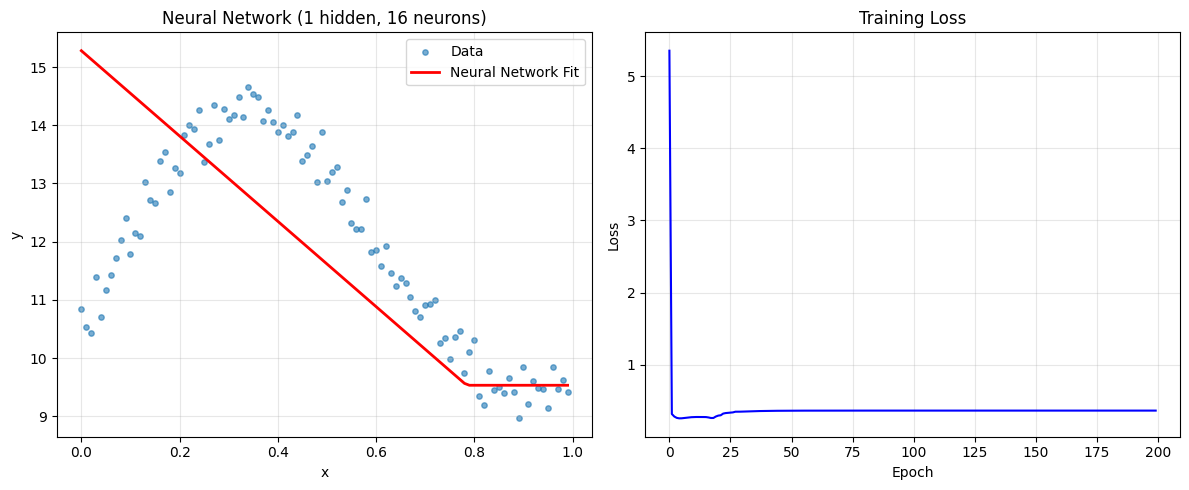

Final loss: 0.367074


In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ===== 准备非线性数据 =====
_x = [ele / 100 for ele in range(100)]
_y = [3 * np.sin(5 * ele) + ele * 2 + 10 + random.random() for ele in _x]

# ===== 两层神经网络（手动实现）=====
# 结构: 输入(1) → 隐藏层(16个神经元, ReLU) → 输出(1)

np.random.seed(42)
n_hidden = 16

# 初始化参数
W1 = np.random.randn(1, n_hidden) * 0.5      # (1, 16)
b1 = np.zeros((1, n_hidden))                  # (1, 16)
W2 = np.random.randn(n_hidden, 1) * 0.5       # (16, 1)
b2 = np.zeros((1, 1))

lr = 0.05
epochs = 200

loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    for xi, yi in zip(_x, _y):
        x = np.array([[xi]])  # (1, 1)
        y_true = yi
        
        # --- 前向传播 ---
        z1 = x @ W1 + b1       # (1, 16)
        a1 = np.maximum(0, z1) # ReLU 激活
        z2 = a1 @ W2 + b2      # (1, 1)
        y_pred = z2[0, 0]
        
        # --- 损失 (MSE) ---
        loss = (y_pred - y_true) ** 2
        epoch_loss += loss
        
        # --- 反向传播 ---
        dz2 = 2 * (y_pred - y_true)  # (1,)
        dW2 = a1.T * dz2             # (16, 1)
        db2 = dz2                    # (1,)
        
        da1 = dz2 * W2.T             # (1, 16)
        dz1 = da1 * (z1 > 0)         # ReLU 导数
        dW1 = x.T @ dz1              # (1, 16)
        db1 = dz1                    # (1, 16)
        
        # --- SGD 更新 ---
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
    
    loss_history.append(epoch_loss / len(_x))

# ===== 用训练好的模型预测 =====
pred_y = []
for xi in _x:
    x = np.array([[xi]])
    z1 = x @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    pred_y.append(z2[0, 0])

# ===== 绘图 =====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(_x, _y, s=15, alpha=0.6, label='Data')
plt.plot(_x, pred_y, 'r-', linewidth=2, label='Neural Network Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Neural Network (1 hidden, {n_hidden} neurons)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss: {loss_history[-1]:.6f}")

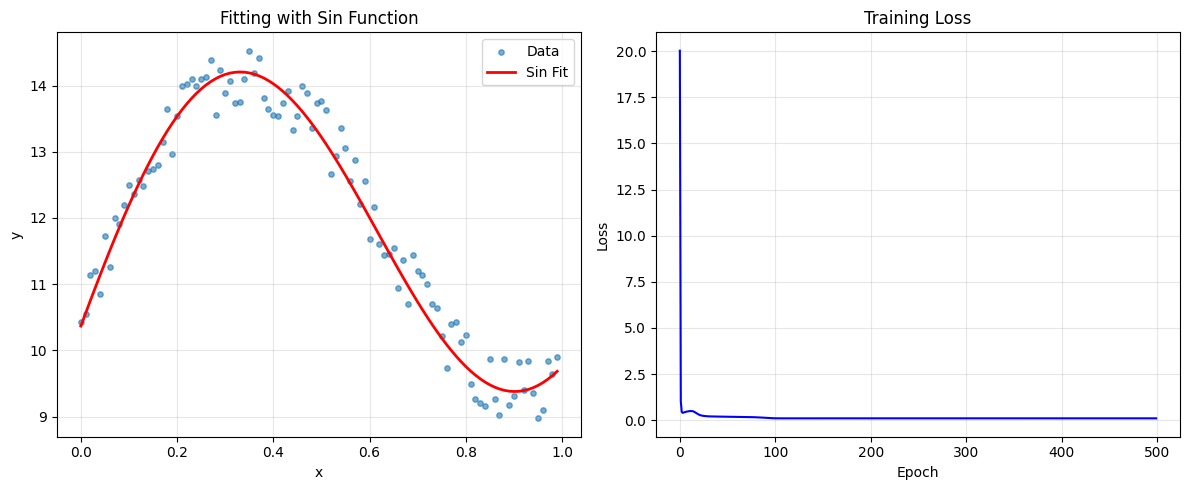

Fitted:  A=3.463  ω=4.774  φ=0.199  w=3.420  b=9.684
Target:  A=3.0     ω=5.0      φ=0.0      w=2.0     b=10.0
Final loss: 0.102927


In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# ===== 准备数据 =====
_x = [ele / 100 for ele in range(100)]
_y = [3 * np.sin(5 * ele) + ele * 2 + 10 + random.random() for ele in _x]

# ===== 用 sin 函数做拟合 =====
# 模型: y = A * sin(ω*x + φ) + w*x + b
# 参数: A, ω, φ, w, b

A = random.random() * 3      # 振幅
omega = random.random() * 5  # 频率
phi = random.random() * 3    # 相位
w = random.random()          # 线性项斜率
b = random.random() * 10     # 截距

lr = 0.01
epochs = 500

loss_history = []

for epoch in range(epochs):
    epoch_loss = 0
    for xi, yi in zip(_x, _y):
        # 前向
        pred = A * math.sin(omega * xi + phi) + w * xi + b
        loss = (pred - yi) ** 2
        epoch_loss += loss
        
        # 反向（手动求导）
        dA = 2 * (pred - yi) * math.sin(omega * xi + phi)
        d_omega = 2 * (pred - yi) * A * math.cos(omega * xi + phi) * xi
        d_phi = 2 * (pred - yi) * A * math.cos(omega * xi + phi)
        dw = 2 * (pred - yi) * xi
        db = 2 * (pred - yi) * 1
        
        # SGD 更新
        A -= lr * dA
        omega -= lr * d_omega
        phi -= lr * d_phi
        w -= lr * dw
        b -= lr * db
    
    loss_history.append(epoch_loss / len(_x))

# ===== 预测 =====
pred_y = [A * math.sin(omega * xi + phi) + w * xi + b for xi in _x]

# ===== 绘图 =====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(_x, _y, s=15, alpha=0.6, label='Data')
plt.plot(_x, pred_y, 'r-', linewidth=2, label='Sin Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitting with Sin Function')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 对比真实参数
print(f"Fitted:  A={A:.3f}  ω={omega:.3f}  φ={phi:.3f}  w={w:.3f}  b={b:.3f}")
print(f"Target:  A=3.0     ω=5.0      φ=0.0      w=2.0     b=10.0")
print(f"Final loss: {loss_history[-1]:.6f}")

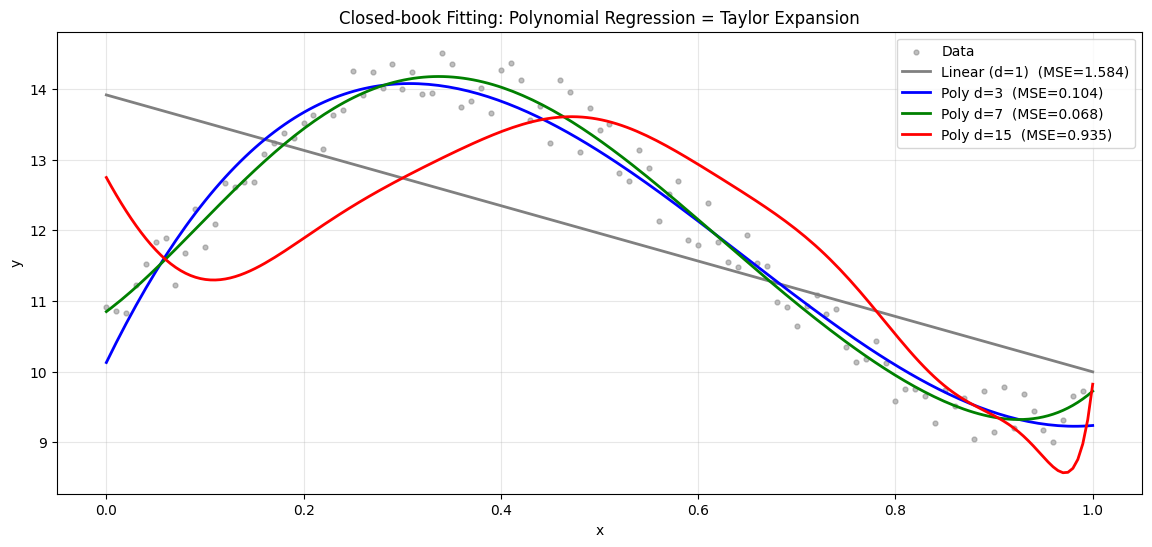

Open-book (known structure):  y = A·sin(ωx+φ) + wx + b
Closed-book (Taylor idea):    y = θ0 + θ1·x + θ2·x² + ... + θd·x^d

【开卷 vs 闭卷对比】

  Open-book  (Sin, 5 params)        |  MSE = 0.0699
  Closed-book (Poly d=15, 16 params) |  MSE = 0.9355

【关键区别】
  Open-book:  参数少、可解释，但需要知道数据结构
  Closed-book: 参数多、通用，但容易过拟合

  就像考试：
  Open-book  ≈ 画了重点 → 效率高，但换题可能不会
  Closed-book ≈ 没画重点 → 多背点公式，啥题都能做


In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# ===== 准备数据 =====
_x = np.array([ele / 100 for ele in range(100)])
_y = np.array([3 * np.sin(5 * ele) + ele * 2 + 10 + random.random() for ele in _x])

# ===== 闭卷方法：多项式回归（泰勒展开思想）=====
# 用 x^0, x^1, x^2, ..., x^d 的线性组合来逼近任意函数
# y ≈ θ0 + θ1·x + θ2·x² + θ3·x³ + ... + θd·x^d

def poly_features(x, degree):
    """将 x 扩展为 [1, x, x², x³, ..., x^d]"""
    return np.array([x ** i for i in range(degree + 1)]).T

def poly_predict(theta, x, degree):
    return poly_features(x, degree) @ theta

# 用不同的多项式次数拟合
degrees = [1, 3, 7, 15]
colors = ['gray', 'blue', 'green', 'red']
labels = ['Linear (d=1)', 'Poly d=3', 'Poly d=7', 'Poly d=15']

plt.figure(figsize=(14, 6))
plt.scatter(_x, _y, s=12, alpha=0.5, color='gray', label='Data')

for degree, color, label in zip(degrees, colors, labels):
    # 构造特征矩阵
    X = poly_features(_x, degree)  # (100, d+1)
    
    # 闭式解：最小二乘法 θ = (X^T X)^{-1} X^T y
    theta = np.linalg.inv(X.T @ X) @ X.T @ _y
    
    # 预测
    pred = X @ theta
    loss = np.mean((pred - _y) ** 2)
    
    # 画出拟合曲线
    x_smooth = np.linspace(0, 1, 200)
    y_smooth = poly_predict(theta, x_smooth, degree)
    plt.plot(x_smooth, y_smooth, '-', color=color, linewidth=2,
             label=f'{label}  (MSE={loss:.3f})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Closed-book Fitting: Polynomial Regression = Taylor Expansion')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ===== 对比：开卷（Sin） vs 闭卷（Poly d=15）=====
print("=" * 50)
print("Open-book (known structure):  y = A·sin(ωx+φ) + wx + b")
print("Closed-book (Taylor idea):    y = θ0 + θ1·x + θ2·x² + ... + θd·x^d")
print("=" * 50)
print()
print("【开卷 vs 闭卷对比】")
print()

# 重新用 sin 拟合（开卷）
A = random.random() * 3
omega = random.random() * 5
phi = random.random() * 3
w = random.random()
b = random.random() * 10
lr_sin = 0.01

for epoch in range(500):
    for xi, yi in zip(_x, _y):
        pred = A * math.sin(omega * xi + phi) + w * xi + b
        dA = 2 * (pred - yi) * math.sin(omega * xi + phi)
        d_omega = 2 * (pred - yi) * A * math.cos(omega * xi + phi) * xi
        d_phi = 2 * (pred - yi) * A * math.cos(omega * xi + phi)
        dw = 2 * (pred - yi) * xi
        db = 2 * (pred - yi)
        A -= lr_sin * dA
        omega -= lr_sin * d_omega
        phi -= lr_sin * d_phi
        w -= lr_sin * dw
        b -= lr_sin * db

sin_pred = [A * math.sin(omega * xi + phi) + w * xi + b for xi in _x]
sin_loss = np.mean((np.array(sin_pred) - _y) ** 2)

# 闭卷：Poly d=15
X15 = poly_features(_x, 15)
theta15 = np.linalg.inv(X15.T @ X15) @ X15.T @ _y
poly_pred = X15 @ theta15
poly_loss = np.mean((poly_pred - _y) ** 2)

# 闭卷：ReLU 神经网络（已有）
print(f"  Open-book  (Sin, 5 params)        |  MSE = {sin_loss:.4f}")
print(f"  Closed-book (Poly d=15, 16 params) |  MSE = {poly_loss:.4f}")
print()
print("【关键区别】")
print("  Open-book:  参数少、可解释，但需要知道数据结构")
print("  Closed-book: 参数多、通用，但容易过拟合")
print()
print("  就像考试：")
print("  Open-book  ≈ 画了重点 → 效率高，但换题可能不会")
print("  Closed-book ≈ 没画重点 → 多背点公式，啥题都能做")